<a href="https://colab.research.google.com/github/gayathri9381/TNS.ipynb/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
df = pd.read_csv("EV_Performance_Final.csv")

df.head()

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating
0,1,Tesla,Model 3,Sedan,60,480,8.0,1.5,225,190,4500000,2023,5
1,2,Tesla,Model Y,SUV,75,530,7.1,1.8,217,220,5500000,2024,5
2,3,Tata,Nexon EV,SUV,40,325,8.1,2.5,150,95,1800000,2023,5
3,4,MG,ZS EV,SUV,50,420,8.4,2.0,175,130,2500000,2022,5
4,5,Hyundai,Kona EV,SUV,39,305,7.8,2.2,167,100,2400000,2023,5


In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_ID        15 non-null     int64  
 1   Manufacturer      15 non-null     object 
 2   Model             15 non-null     object 
 3   Vehicle_Type      15 non-null     object 
 4   Battery_Capacity  15 non-null     int64  
 5   Range             15 non-null     int64  
 6   Efficiency        15 non-null     float64
 7   Charging_Time     15 non-null     float64
 8   Top_Speed         15 non-null     int64  
 9   Motor_Power       15 non-null     int64  
 10  Price             15 non-null     int64  
 11  Launch_Year       15 non-null     int64  
 12  Safety_Rating     15 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.7+ KB
None
       Vehicle_ID  Battery_Capacity       Range  Efficiency  Charging_Time  \
count   15.000000         15.000000   15.000000

In [ ]:
def calculate_efficiency(vehicle_range, battery):
    return vehicle_range / battery

df["Calculated_Efficiency"] = df.apply(
    lambda x: calculate_efficiency(x["Range"], x["Battery_Capacity"]),
    axis=1
)

print(df[["Model","Calculated_Efficiency"]])

            Model  Calculated_Efficiency
0         Model 3               8.000000
1         Model Y               7.066667
2        Nexon EV               8.125000
3           ZS EV               8.400000
4         Kona EV               7.820513
5          XUV400               9.615385
6          Atto 3               8.683333
7            Leaf               6.750000
8             EV6               6.857143
9              i4               7.375000
10         e-tron               5.094737
11            EQA               6.358209
12  XC40 Recharge               6.794872
13        Kwid EV               7.333333
14           bZ4X               7.042254


In [ ]:
def classify_vehicle(efficiency):

    if efficiency > 8:
        return "Excellent"

    elif efficiency >= 6:
        return "Good"

    elif efficiency >= 4:
        return "Average"

    else:
        return "Poor"

df["Category"] = df["Calculated_Efficiency"].apply(classify_vehicle)

print(df[["Model","Calculated_Efficiency","Category"]])

            Model  Calculated_Efficiency   Category
0         Model 3               8.000000       Good
1         Model Y               7.066667       Good
2        Nexon EV               8.125000  Excellent
3           ZS EV               8.400000  Excellent
4         Kona EV               7.820513       Good
5          XUV400               9.615385  Excellent
6          Atto 3               8.683333  Excellent
7            Leaf               6.750000       Good
8             EV6               6.857143       Good
9              i4               7.375000       Good
10         e-tron               5.094737    Average
11            EQA               6.358209       Good
12  XC40 Recharge               6.794872       Good
13        Kwid EV               7.333333       Good
14           bZ4X               7.042254       Good


In [ ]:
filtered = df[
    (df["Range"] > 400) &
    (df["Charging_Time"] < 2) &
    (df["Safety_Rating"] >= 4)
]

print(filtered)

   Vehicle_ID Manufacturer    Model Vehicle_Type  Battery_Capacity  Range  \
0           1        Tesla  Model 3        Sedan                60    480   
1           2        Tesla  Model Y          SUV                75    530   
6           7          BYD   Atto 3          SUV                60    521   
8           9          Kia      EV6          SUV                77    528   
9          10          BMW       i4        Sedan                80    590   

   Efficiency  Charging_Time  Top_Speed  Motor_Power    Price  Launch_Year  \
0         8.0            1.5        225          190  4500000         2023   
1         7.1            1.8        217          220  5500000         2024   
6         8.7            1.7        160          150  3400000         2024   
8         6.9            1.4        192          239  6200000         2024   
9         7.4            1.8        225          250  7200000         2024   

   Safety_Rating  Calculated_Efficiency   Category  
0              

In [ ]:
battery = df["Battery_Capacity"].values
vehicle_range = df["Range"].values
price = df["Price"].values
motor = df["Motor_Power"].values
charging = df["Charging_Time"].values

**NUMPY**

In [ ]:
# Mean Battery Capacity
print(np.mean(battery))

60.06666666666667


In [ ]:
# Mean Range
print(np.mean(vehicle_range))

433.6


In [ ]:
# Standard Deviation of Prices
print(np.std(price))

2424724.4975231495


In [ ]:
# Maximum Motor Power
print(np.max(motor))

300


In [ ]:
# Minimum Charging Time
print(np.min(charging))

1.4


In [ ]:
# battery capacity vs Range
print(np.corrcoef(battery, vehicle_range))

[[1.         0.86624028]
 [0.86624028 1.        ]]


In [ ]:
# price vs motor power
print(np.corrcoef(price, motor))

In [ ]:
# Charging Time vs Battery Capacity
print(np.corrcoef(charging, battery))

**PANDAS**

In [ ]:
# Most Expensive Vehicle
print(df.loc[df["Price"].idxmax()])

Vehicle_ID                     11
Manufacturer                 Audi
Model                      e-tron
Vehicle_Type                  SUV
Battery_Capacity               95
Range                         484
Efficiency                    5.1
Charging_Time                 2.5
Top_Speed                     200
Motor_Power                   300
Price                     9800000
Launch_Year                  2023
Safety_Rating                   5
Calculated_Efficiency    5.094737
Category                  Average
Name: 10, dtype: object


In [ ]:
# Cheapest Vehicle
print(df.loc[df["Price"].idxmin()])

Vehicle_ID                      14
Manufacturer               Renault
Model                      Kwid EV
Vehicle_Type             Hatchback
Battery_Capacity                30
Range                          220
Efficiency                     7.3
Charging_Time                  3.5
Top_Speed                      125
Motor_Power                     50
Price                       900000
Launch_Year                   2022
Safety_Rating                    4
Calculated_Efficiency     7.333333
Category                      Good
Name: 13, dtype: object


In [ ]:
# Maximum Range
print(df.loc[df["Range"].idxmax()])

Vehicle_ID                    10
Manufacturer                 BMW
Model                         i4
Vehicle_Type               Sedan
Battery_Capacity              80
Range                        590
Efficiency                   7.4
Charging_Time                1.8
Top_Speed                    225
Motor_Power                  250
Price                    7200000
Launch_Year                 2024
Safety_Rating                  5
Calculated_Efficiency      7.375
Category                    Good
Name: 9, dtype: object


In [ ]:
# Highest Efficiency
print(df.loc[df["Calculated_Efficiency"].idxmax()])

Vehicle_ID                       6
Manufacturer              Mahindra
Model                       XUV400
Vehicle_Type                   SUV
Battery_Capacity                39
Range                          375
Efficiency                     9.6
Charging_Time                  2.0
Top_Speed                      150
Motor_Power                    110
Price                      2000000
Launch_Year                   2023
Safety_Rating                    5
Calculated_Efficiency     9.615385
Category                 Excellent
Name: 5, dtype: object


In [ ]:
#Manufacturer-wise Average
manufacturer = df.groupby("Manufacturer")[["Price","Range","Battery_Capacity"]].mean()

print(manufacturer)

                  Price  Range  Battery_Capacity
Manufacturer                                    
Audi          9800000.0  484.0              95.0
BMW           7200000.0  590.0              80.0
BYD           3400000.0  521.0              60.0
Hyundai       2400000.0  305.0              39.0
Kia           6200000.0  528.0              77.0
MG            2500000.0  420.0              50.0
Mahindra      2000000.0  375.0              39.0
Mercedes      6500000.0  426.0              67.0
Nissan        2900000.0  270.0              40.0
Renault        900000.0  220.0              30.0
Tata          1800000.0  325.0              40.0
Tesla         5000000.0  505.0              67.5
Toyota        4500000.0  500.0              71.0
Volvo         7000000.0  530.0              78.0


**MATPLOTLIB**

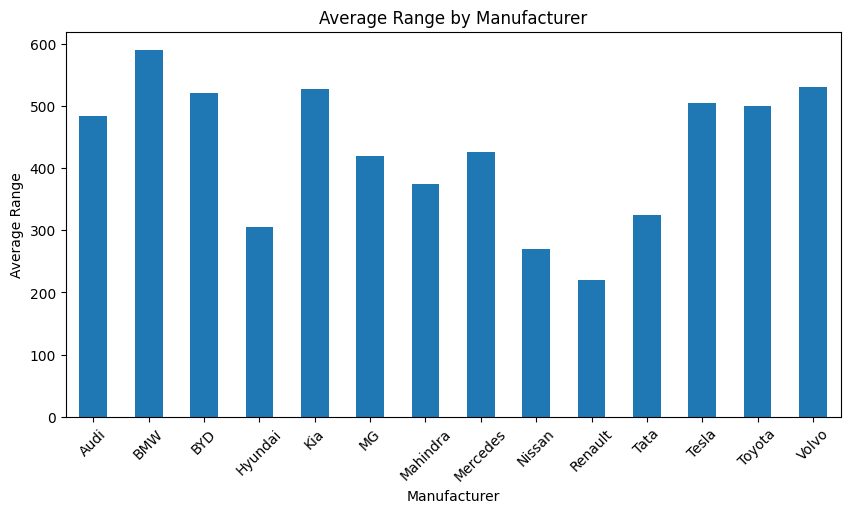

In [ ]:
# bar plot
avg_range = df.groupby("Manufacturer")["Range"].mean()

plt.figure(figsize=(10,5))

avg_range.plot(kind="bar")

plt.title("Average Range by Manufacturer")

plt.xlabel("Manufacturer")

plt.ylabel("Average Range")

plt.xticks(rotation=45)

plt.show()

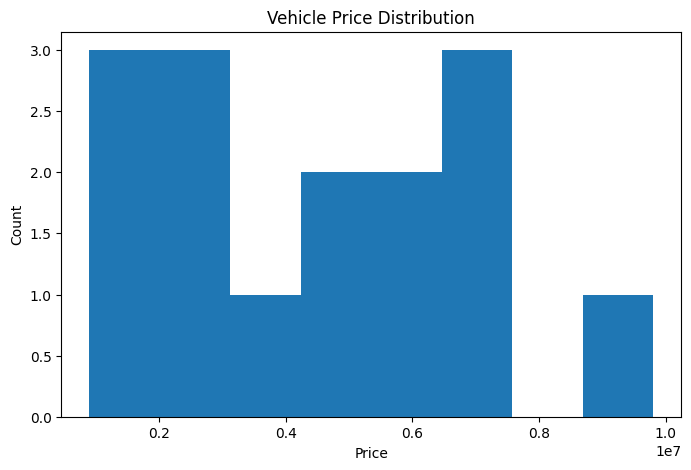

In [ ]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=8)

plt.title("Vehicle Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

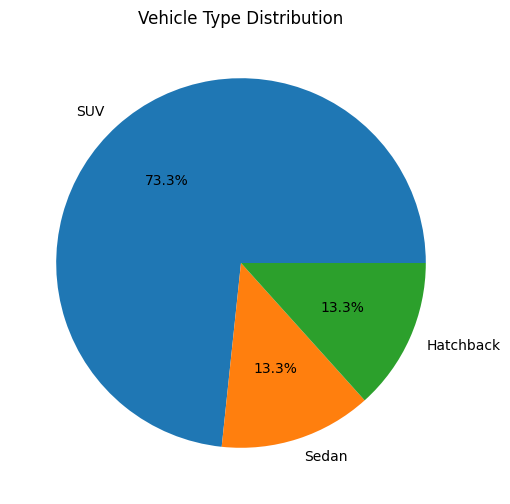

In [ ]:
# pie chart
vehicle = df["Vehicle_Type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(vehicle,
        labels=vehicle.index,
        autopct="%1.1f%%")

plt.title("Vehicle Type Distribution")

plt.show()

**SEABORN**

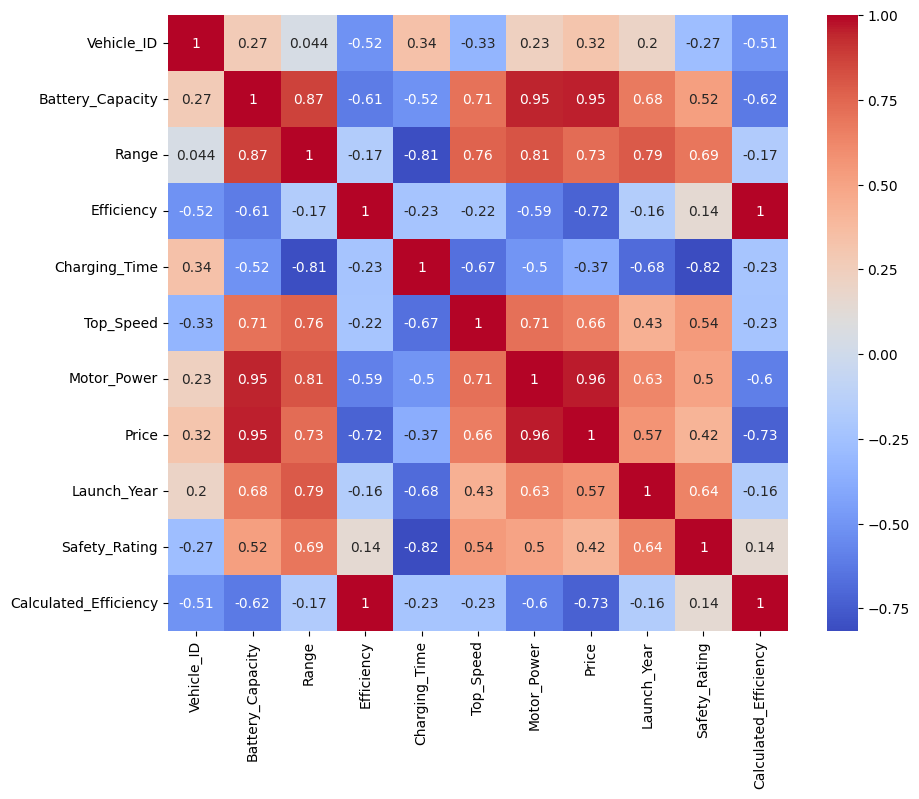

In [ ]:
# heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

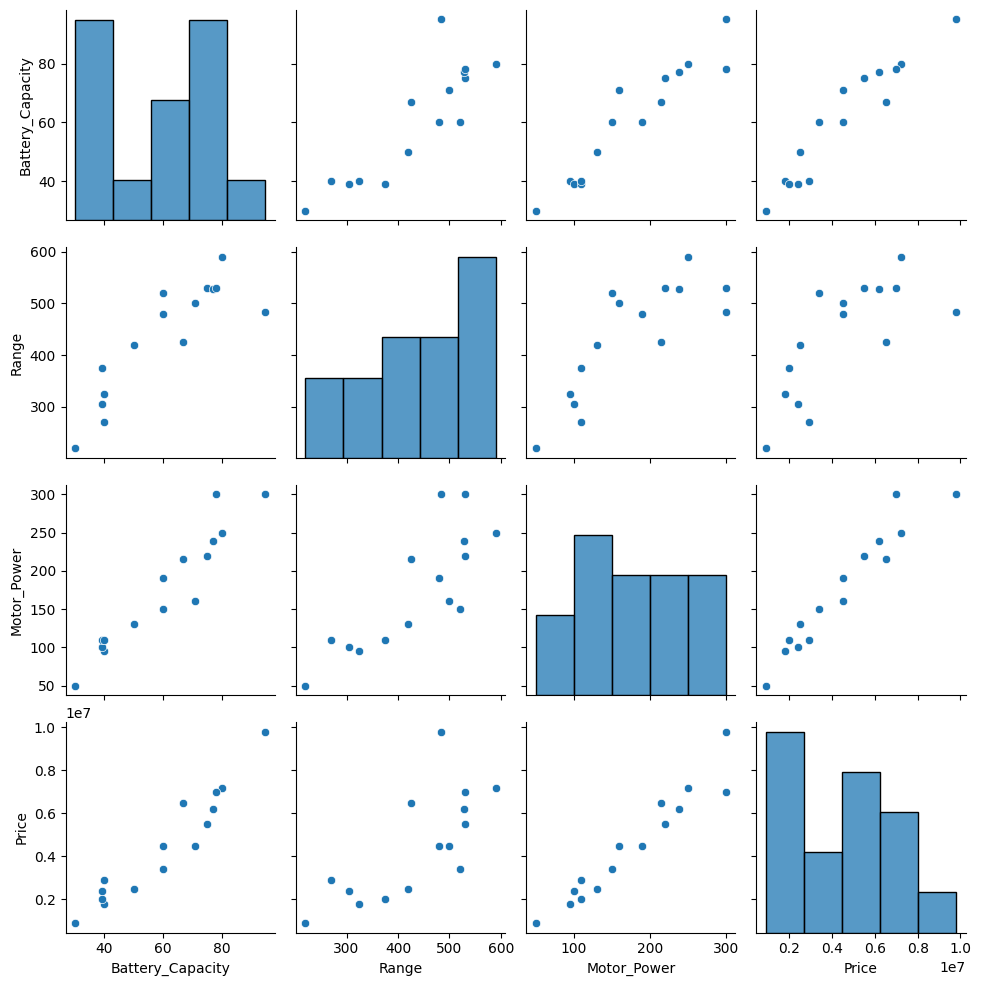

In [ ]:
# Pairplot
sns.pairplot(df[[
    "Battery_Capacity",
    "Range",
    "Motor_Power",
    "Price"
]])

plt.show()

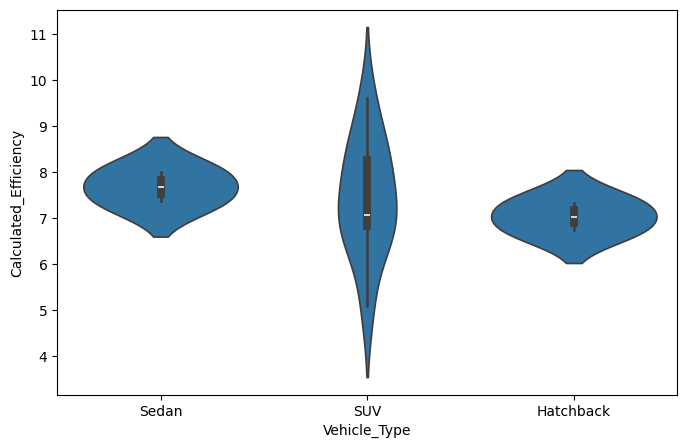

In [ ]:
# violin plot
plt.figure(figsize=(8,5))

sns.violinplot(
    x="Vehicle_Type",
    y="Calculated_Efficiency",
    data=df
)

plt.show()

**PLOTLY**

In [ ]:
# Interactive Scatter Plot
fig = px.scatter(
    df,
    x="Battery_Capacity",
    y="Range",
    color="Manufacturer",
    size="Price",
    hover_name="Model",
    title="Electric Vehicle Performance Analysis"
)

fig.show()

In [ ]:
# Dropdown menu
manufacturers = df["Manufacturer"].unique()

fig = go.Figure()

for company in manufacturers:

    temp = df[df["Manufacturer"] == company]

    fig.add_trace(
        go.Scatter(
            x=temp["Battery_Capacity"],
            y=temp["Range"],
            mode="markers",
            marker=dict(
                size=temp["Price"]/500000,
                sizemode="area"
            ),
            text=temp["Model"],
            name=company,
            visible=False
        )
    )

fig.data[0].visible = True

buttons = []

for i, company in enumerate(manufacturers):

    visible = [False]*len(manufacturers)

    visible[i] = True

    buttons.append(
        dict(
            label=company,
            method="update",
            args=[
                {"visible": visible},
                {"title": company + " Vehicles"}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True
        )
    ],
    xaxis_title="Battery Capacity (kWh)",
    yaxis_title="Range (km)"
)

fig.show()